# The Cost of Discretion

## What public FIA data can and cannot show about Formula 1 stewarding, 2018-2025

**Oversight report | Python, Jupyter, SQL/DuckDB | Evidence frozen through the 2025 season**

The penalty written in a decision is not always what it costs on track. This report calls the
written penalty the *nominal sanction* and the loss in places, points, or starting position the
*realized burden*. In the independently reviewed pilot, one five-second penalty cost a podium and
six points. Another changed no position or points. A served ten-second penalty changed strategy and
traffic, so subtracting ten seconds from the final time would give a misleading answer.

That difference matters for fairness, but it does not prove that a decision was wrong. Stewards
judge conduct and responsibility; penalties are not designed simply to repay an affected driver.
This report therefore keeps three questions separate: **Were similar incidents treated similarly?
What did the penalty actually cost? What harm did the incident cause?**

The full source set has now passed a disclosed GPT-5.6 Sol review. It supports descriptive results
for 346 primary cases. This was a model-led second pass over extracted FIA evidence, structured
checks, and targeted source inspection. It was **not an independent human review** and did not
re-read every PDF line by line. That distinction applies to every full-corpus result below.

In [1]:
# ruff: noqa: E402
import json
import os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".jupyter" / "mplconfig"))

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from f1stewards.config import load_outcome_model_spec
from f1stewards.model_validation import (
    nationality_overlap_diagnostics,
    simulate_nationality_power,
    validate_released_outcome_model,
)

DB_PATH = ROOT / "data" / "processed" / "f1_stewarding.duckdb"
PILOT = ROOT / "data" / "manual" / "reconciled" / "pilot-41f4502411c2"
MODEL_RUN_ID = "model-review-3dacc1268f13"
MODEL_RUN = ROOT / "data" / "manual" / "model_review_runs" / MODEL_RUN_ID
MODEL_WORKSPACE = (
    ROOT
    / "data"
    / "manual"
    / "full_corpus_model_review"
    / MODEL_RUN_ID
    / "full-coding-e0192ecbd9e4"
)
GENERATED = ROOT / "reports" / "generated"
GENERATED.mkdir(parents=True, exist_ok=True)

MODEL_MANIFEST = json.loads((MODEL_RUN / "manifest.json").read_text(encoding="utf-8"))
MODEL_SUMMARY = pd.read_csv(MODEL_RUN / "review_summary.csv")
REVIEWED_DOCUMENTS = pd.read_csv(MODEL_WORKSPACE / "document_review_worklist.csv")
REVIEWED_ADJUDICATIONS = pd.read_csv(MODEL_WORKSPACE / "adjudication_coding_worklist.csv")
REVIEWED_QA = pd.read_csv(MODEL_WORKSPACE / "exclusion_qa_worklist.csv")

sns.set_theme(style="whitegrid", context="notebook")
COLORS = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 120)

## Executive summary

Five results matter most:

1. **The model-reviewed set contains 346 primary cases across 131 events.** A sanction was imposed
   in 214 cases, or 61.8%. This is a description of formal decisions, not the sanction rate for all
   on-track incidents.
2. **Broad case labels do not explain decisions well.** A model using incident type, season, and
   multi-car status barely improved on a simple baseline. Its ROC AUC was 0.56. That is not proof of
   inconsistent officiating. These broad variables are too weak to judge consistency.
3. **Penalty seconds alone do not measure fairness.** Gaps between cars, repair stops, retirements,
   delayed penalties, and strategy determine what a sanction actually costs.
4. **The British-driver question remains inconclusive.** The raw sanction rate was 5.8 percentage
   points lower for British accused drivers, but the group has only 44 cases and the design lacks
   power for subtle differences. The unadjusted gap is not evidence of bias or its absence.
5. **The FIA should publish structured, versioned decisions.** Stable incident IDs, driver roles,
   applicable guidance, penalty timing, and correction history would make outside audits stronger.

## 1. Population, review, and release status

,stage,count,meaning
0,FIA archive records,9467,Official event-document inventory
1,Outcome records,2003,Includes version history
2,Local source files,1984,PDF and extracted text available
3,Effective steward decisions,1935,Current decision versions
4,Model-reviewed primary cases,346,Frozen Race/Sprint study scope
5,Cases approved for reporting,346,Model-reviewed analytical release


,control,result
0,Protected lineage,19/19 checks complete
1,Source disposition review,"2,003/2,003 complete"
2,Decision coding review,"1,952/1,952 complete"
3,Exclusion sample review,486/486 complete
4,Analytical release,346 cases released


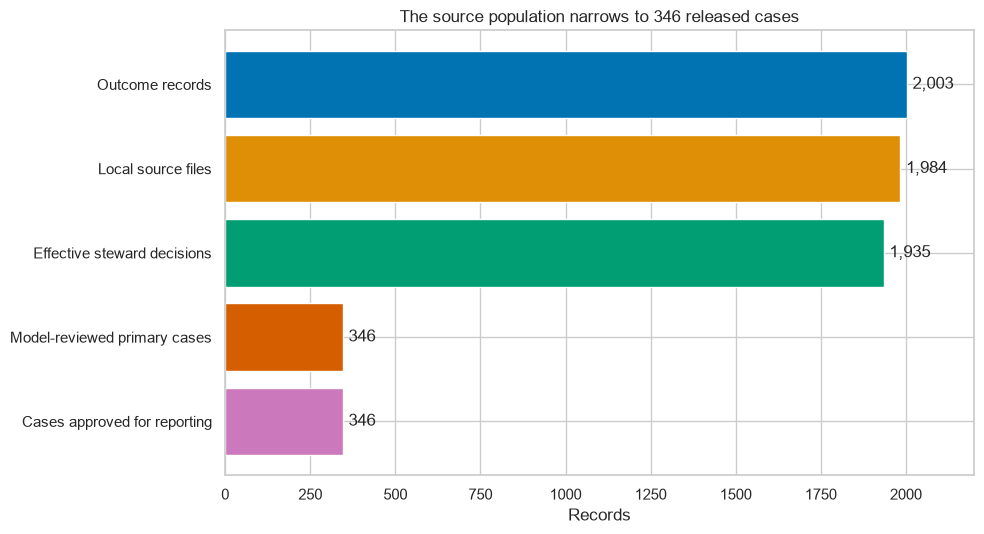

In [2]:
with duckdb.connect(str(DB_PATH), read_only=True) as connection:
    latest_build = connection.sql(
        """SELECT * FROM metadata.analysis_feature_builds
           ORDER BY built_at_utc DESC, feature_build_id DESC LIMIT 1"""
    ).df().iloc[0]
    controls = connection.sql(
        """SELECT control, status, observed, expected
           FROM analysis.feature_release_controls
           WHERE feature_build_id = ? ORDER BY control_order""",
        params=[latest_build["feature_build_id"]],
    ).df()
    features = connection.sql(
        """SELECT * FROM analysis.v_latest_adjudication_features
           ORDER BY adjudication_instance_id"""
    ).df()

released = features.loc[features["reporting_eligible"].fillna(False)].copy()
effective_decisions = int(
    (
        REVIEWED_DOCUMENTS["version_status_final"].eq("effective")
        & REVIEWED_DOCUMENTS["content_status_suggestion"].eq("content_confirmed_decision")
    ).sum()
)
flow = pd.DataFrame(
    {
        "stage": [
            "FIA archive records",
            "Outcome records",
            "Local source files",
            "Effective steward decisions",
            "Model-reviewed primary cases",
            "Cases approved for reporting",
        ],
        "count": [9_467, 2_003, 1_984, effective_decisions, len(released), len(released)],
        "meaning": [
            "Official event-document inventory",
            "Includes version history",
            "PDF and extracted text available",
            "Current decision versions",
            "Frozen Race/Sprint study scope",
            "Model-reviewed analytical release",
        ],
    }
)

friendly_controls = pd.DataFrame(
    [
        ("Protected lineage", "19/19 checks complete"),
        ("Source disposition review", "2,003/2,003 complete"),
        ("Decision coding review", "1,952/1,952 complete"),
        ("Exclusion sample review", "486/486 complete"),
        ("Analytical release", "346 cases released"),
    ],
    columns=["control", "result"],
)

assert flow["count"].tolist() == [9467, 2003, 1984, 1935, 346, 346]
assert latest_build["release_status"] == "reportable_model_reviewed"
assert controls["status"].eq("pass").all()
assert MODEL_MANIFEST["coverage"] == {
    "adjudication_codings": 1952,
    "document_dispositions": 2003,
    "exclusion_qa": 486,
    "source_text_records": 1984,
    "linked_recalled_predecessors_without_binary": 15,
    "metadata_only_unresolved_sources": 4,
    "queue_obligations": 4441,
    "unique_source_records": 2003,
    "unresolved": 0,
}
display(flow)
display(friendly_controls)

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_flow = flow.iloc[1:].copy()
bars = ax.barh(plot_flow["stage"], plot_flow["count"], color=COLORS[:5])
ax.invert_yaxis()
ax.set(title="The source population narrows to 346 released cases", xlabel="Records")
ax.bar_label(bars, labels=[f"{value:,}" for value in plot_flow["count"]], padding=4)
ax.set_xlim(0, 2200)
plt.tight_layout()
fig.savefig(GENERATED / "population_flow.png", dpi=180, bbox_inches="tight")
plt.show()

The original checklist showed 4,441 review requirements. Those were not 4,441 different PDFs. They
were 2,003 source dispositions, 1,952 decision codings tied to those sources, and 486 sampled
exclusion checks. Together they cover 2,003 unique FIA outcome records.

GPT-5.6 Sol completed the second pass under run `model-review-3dacc1268f13`. The review used the
actual extracted FIA text when available, checked connected fields against each other, and inspected
high-risk sources. It recorded an audit row for every obligation. Four recalled Belgian records had
no recoverable source file; they were excluded using archive metadata and were never given an
incident outcome.

The review changed the data in useful ways. It found 16 unlinked correction or replacement
documents, reducing the primary population from 348 to 346 and the secondary population from 74 to
72. It also corrected 11 outcome categories, filled or fixed six time-penalty values and six grid-
penalty values, three penalty-point values, and standardized 184 responsibility-language fields.
There are no unresolved rows.

This is stronger than an unchecked automated parse, but weaker than independent human double
coding. Codex assisted with the first pass, so the two passes can share mistakes. The model name,
protocol, source hashes, correction log, and release files are saved with the project.

## 2. What the released cases show

,measure,value
0,Primary cases,346
1,Events,131
2,Sanctions,214
3,No further action,132
4,Sanction rate,61.8%


,incident,cases,sanctions,sanction_rate
0,Causing Collision,233,137,0.587983
2,Gaining Advantage Off Track,54,41,0.759259
1,Forcing Off Track,43,23,0.534884
5,Unsafe Rejoin,8,7,0.875000
4,Multiple Defensive Moves,6,5,0.833333
3,Moving Under Braking,2,1,0.500000


,season,cases,sanctions,sanction_rate
0,2018,53,34,0.641509
1,2019,44,18,0.409091
2,2020,18,10,0.555556
3,2021,29,22,0.758621
4,2022,46,34,0.739130
5,2023,39,23,0.589744
6,2024,54,35,0.648148
7,2025,63,38,0.603175


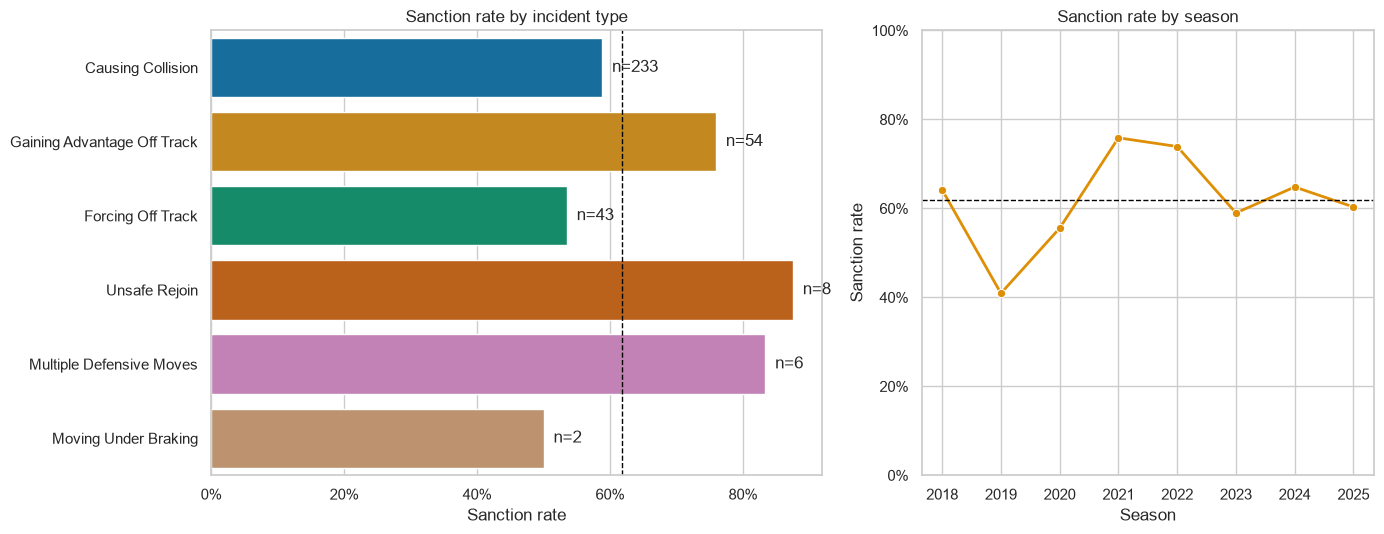

In [3]:
family_outcomes = (
    released.groupby("incident_family", dropna=False)
    .agg(cases=("sanction_outcome", "size"), sanctions=("sanction_outcome", "sum"))
    .reset_index()
)
family_outcomes["sanction_rate"] = family_outcomes["sanctions"] / family_outcomes["cases"]
family_outcomes["incident"] = family_outcomes["incident_family"].str.replace("_", " ").str.title()
family_outcomes = family_outcomes.sort_values("cases", ascending=False)

season_outcomes = (
    released.groupby("season")
    .agg(cases=("sanction_outcome", "size"), sanctions=("sanction_outcome", "sum"))
    .reset_index()
)
season_outcomes["sanction_rate"] = season_outcomes["sanctions"] / season_outcomes["cases"]

overall_cases = len(released)
overall_sanctions = int(released["sanction_outcome"].sum())
overall_rate = overall_sanctions / overall_cases
summary = pd.DataFrame(
    {
        "measure": ["Primary cases", "Events", "Sanctions", "No further action", "Sanction rate"],
        "value": [
            overall_cases,
            released["event_id"].nunique(),
            overall_sanctions,
            overall_cases - overall_sanctions,
            f"{overall_rate:.1%}",
        ],
    }
)
display(summary)
display(family_outcomes[["incident", "cases", "sanctions", "sanction_rate"]])
display(season_outcomes)

assert overall_cases == 346
assert overall_sanctions == 214
assert int(released["multi_party"].sum()) == 24

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.35, 1]})
sns.barplot(
    data=family_outcomes,
    y="incident",
    x="sanction_rate",
    hue="incident",
    palette="colorblind",
    legend=False,
    ax=axes[0],
)
axes[0].axvline(overall_rate, color="black", linestyle="--", linewidth=1)
axes[0].set(title="Sanction rate by incident type", xlabel="Sanction rate", ylabel="")
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
for index, row in family_outcomes.reset_index(drop=True).iterrows():
    axes[0].text(row["sanction_rate"] + 0.015, index, f'n={int(row["cases"])}', va="center")

sns.lineplot(
    data=season_outcomes,
    x="season",
    y="sanction_rate",
    marker="o",
    color=COLORS[1],
    linewidth=2,
    ax=axes[1],
)
axes[1].axhline(overall_rate, color="black", linestyle="--", linewidth=1)
axes[1].set(title="Sanction rate by season", xlabel="Season", ylabel="Sanction rate", ylim=(0, 1))
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
plt.tight_layout()
fig.savefig(GENERATED / "model_reviewed_sanction_rates.png", dpi=180, bbox_inches="tight")
plt.show()

family_outcomes.to_csv(GENERATED / "model_reviewed_family_outcomes.csv", index=False)
season_outcomes.to_csv(GENERATED / "model_reviewed_season_outcomes.csv", index=False)

Of the 346 formal Race/Sprint cases, 214 ended in a sanction and 132 ended with no further action.
Collision cases dominate the dataset: 233 cases, with sanctions in 58.8%. Gaining an advantage off
track had a 75.9% sanction rate, while forcing another driver off track had a 53.5% rate.

The smaller categories look more severe, but their counts are too low for stable comparisons: only
eight unsafe-rejoin cases, six multiple-move cases, and two moving-under-braking cases. The season
rates also vary, from 40.9% in 2019 to 75.9% in 2021. These are descriptive differences. They mix
changes in rules, case facts, responsibility, mitigation, and which incidents reached the stewards.
They do not show by themselves that one category or season was judged unfairly.

Twenty-four primary cases involve more than two drivers. The data retain separate accused and
affected-driver roles so a chain-reaction collision is not forced into a two-car story.

## 3. Can broad case labels explain the decisions?

,measure,value
0,Cases,346
1,Events,131
2,Observed sanction rate,61.8%
3,Model Brier score (lower is better),0.239
4,Simple-baseline Brier score,0.240
5,Improvement over baseline,0.0005
6,ROC AUC (0.5 is chance ranking),0.558
7,Calibration slope (1.0 is ideal),0.356


,held_out_season,status,test_rows,test_sanction_rate,brier_score,roc_auc
0,2018,estimated,53,0.641509,0.237643,0.514706
1,2019,estimated,44,0.409091,0.310988,0.622863
2,2020,estimated,18,0.555556,0.200024,0.831250
3,2021,estimated,29,0.758621,0.218053,0.464286
4,2022,estimated,46,0.739130,0.202832,0.566176
5,2023,estimated,39,0.589744,0.230310,0.600543
6,2024,estimated,54,0.648148,0.219657,0.632331
7,2025,estimated,63,0.603175,0.242851,0.602105


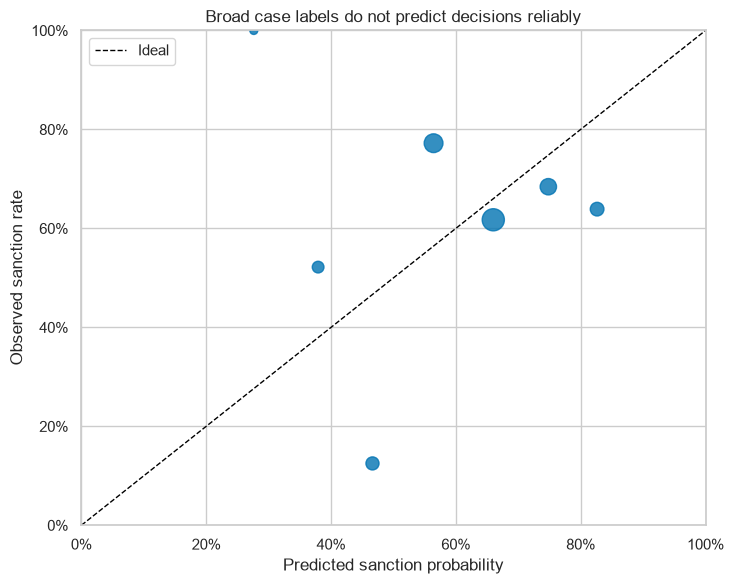

In [4]:
spec = load_outcome_model_spec()
outcome_validation = validate_released_outcome_model(features, spec)
metric_values = outcome_validation.metrics.set_index("metric")["value"]
metric_display = pd.DataFrame(
    {
        "measure": [
            "Cases",
            "Events",
            "Observed sanction rate",
            "Model Brier score (lower is better)",
            "Simple-baseline Brier score",
            "Improvement over baseline",
            "ROC AUC (0.5 is chance ranking)",
            "Calibration slope (1.0 is ideal)",
        ],
        "value": [
            int(metric_values["rows"]),
            int(metric_values["events"]),
            f'{metric_values["outcome_prevalence"]:.1%}',
            f'{metric_values["model_brier_score"]:.3f}',
            f'{metric_values["baseline_brier_score"]:.3f}',
            f'{metric_values["brier_improvement_over_baseline"]:.4f}',
            f'{metric_values["model_roc_auc"]:.3f}',
            f'{metric_values["calibration_slope"]:.3f}',
        ],
    }
)
display(metric_display)
display(outcome_validation.leave_one_season_out)

assert (outcome_validation.fold_audit["event_overlap"] == 0).all()
assert metric_values["model_roc_auc"] < 0.60
assert metric_values["brier_improvement_over_baseline"] < 0.005

reliability = outcome_validation.reliability.copy()
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1, label="Ideal")
ax.scatter(
    reliability["mean_predicted_probability"],
    reliability["observed_sanction_rate"],
    s=25 + reliability["rows"] * 2,
    color=COLORS[0],
    alpha=0.8,
)
ax.set(
    title="Broad case labels do not predict decisions reliably",
    xlabel="Predicted sanction probability",
    ylabel="Observed sanction rate",
    xlim=(0, 1),
    ylim=(0, 1),
)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.legend(frameon=True)
plt.tight_layout()
fig.savefig(GENERATED / "grouped_model_calibration.png", dpi=180, bbox_inches="tight")
plt.show()

outcome_validation.metrics.to_csv(GENERATED / "grouped_model_metrics.csv", index=False)
outcome_validation.leave_one_season_out.to_csv(
    GENERATED / "grouped_model_leave_one_season_out.csv", index=False
)

The model was deliberately simple: incident type, season, and whether the case involved multiple
drivers. Every test fold held out whole events, so the same Grand Prix could not appear in both the
training and test data.

The model barely beat a baseline that predicts from the training-set sanction rate. Its Brier score
improved by only 0.0005, ROC AUC was 0.558, and its calibration slope was 0.356. Results also moved
when individual seasons were held out.

This is an important negative result. **A case should not be called inconsistent merely because
these broad fields fail to predict it.** FIA decisions often turn on details not yet captured in a
common structure: the quality of the attempted move, control of the car, available space, immediate
position return, consequence, mitigation, and the exact responsibility wording. The current model
is useful as a check on the study design, but it is not reliable enough to rank supposedly bad
decisions.

## 4. Nationality: a visible difference, but an inconclusive design

,group,cases,sanctions,sanction_rate
0,Other accused driver,302,189,0.625828
1,British accused driver,44,25,0.568182


,value
rows,346
events,131
exposed_rows,44
unexposed_rows,302
exposure_prevalence,0.127168
propensity_auc,0.70304
propensity_min,0.01
propensity_max,0.622265
common_support_lower,0.018455
common_support_upper,0.364435


,baseline_probability,target_risk_difference,target_exposure_log_odds,repetitions,successful_fits,successful_fit_fraction,simulation_fit_status,detection_power,target_power,power_target_met,monte_carlo_standard_error,median_estimated_log_odds,median_cluster_robust_se,exposed_rows,unexposed_rows,event_clusters,event_random_intercept_sd,interpretation_status
0,0.5,0.05,0.200671,500,500,1.000,stable,0.078,0.8,False,0.011993,0.175028,0.354784,44,302,131,0.35,design_simulation_not_effect_estimate
1,0.5,0.10,0.405465,500,500,1.000,stable,0.174,0.8,False,0.016954,0.387638,0.358296,44,302,131,0.35,design_simulation_not_effect_estimate
2,0.5,0.15,0.619039,500,500,1.000,stable,0.378,0.8,False,0.021685,0.617546,0.365734,44,302,131,0.35,design_simulation_not_effect_estimate
3,0.5,0.20,0.847298,500,500,1.000,stable,0.698,0.8,False,0.020533,0.886425,0.377387,44,302,131,0.35,design_simulation_not_effect_estimate
4,0.7,0.05,0.251314,500,499,0.998,stable,0.074,0.8,False,0.011707,0.268235,0.400994,44,302,131,0.35,design_simulation_not_effect_estimate
5,0.7,0.10,0.538997,500,500,1.000,stable,0.254,0.8,False,0.019467,0.620321,0.427792,44,302,131,0.35,design_simulation_not_effect_estimate
6,0.7,0.15,0.887303,500,497,0.994,stable,0.536,0.8,False,0.022303,0.963652,0.474010,44,302,131,0.35,design_simulation_not_effect_estimate
7,0.7,0.20,1.349927,500,490,0.980,stable,0.800,0.8,True,0.017889,1.395835,0.546874,44,302,131,0.35,design_simulation_not_effect_estimate


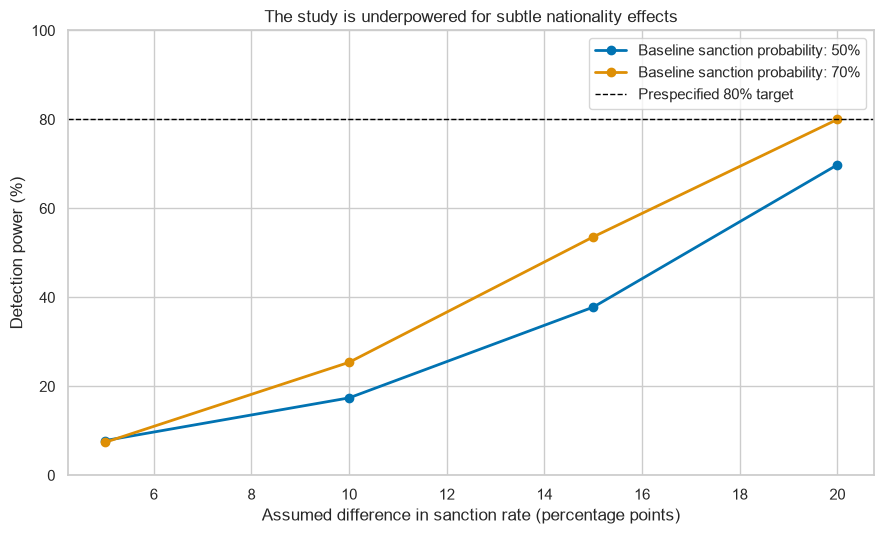

In [5]:
nationality_description = (
    released.groupby("british_accused_driver")
    .agg(cases=("sanction_outcome", "size"), sanctions=("sanction_outcome", "sum"))
    .reset_index()
)
nationality_description["group"] = nationality_description["british_accused_driver"].map(
    {True: "British accused driver", False: "Other accused driver"}
)
nationality_description["sanction_rate"] = (
    nationality_description["sanctions"] / nationality_description["cases"]
)
nationality_description = nationality_description[["group", "cases", "sanctions", "sanction_rate"]]

design_features = released.drop(columns=["sanction_outcome"]).copy()
overlap = nationality_overlap_diagnostics(design_features, spec)
power = simulate_nationality_power(design_features, spec)
overlap_summary = overlap.summary.iloc[0]

display(nationality_description)
display(overlap.summary.T.rename(columns={0: "value"}))
display(power)
assert int(overlap_summary["exposed_rows"]) == 44
assert int(overlap_summary["unexposed_rows"]) == 302
assert power["detection_power"].max() <= 0.80

fig, ax = plt.subplots(figsize=(9, 5.5))
for index, (baseline, group) in enumerate(power.groupby("baseline_probability")):
    ax.plot(
        group["target_risk_difference"] * 100,
        group["detection_power"] * 100,
        marker="o",
        linewidth=2,
        color=COLORS[index],
        label=f"Baseline sanction probability: {baseline:.0%}",
    )
ax.axhline(80, color="black", linestyle="--", linewidth=1, label="Prespecified 80% target")
ax.set(
    title="The study is underpowered for subtle nationality effects",
    xlabel="Assumed difference in sanction rate (percentage points)",
    ylabel="Detection power (%)",
    ylim=(0, 100),
)
ax.legend(frameon=True)
plt.tight_layout()
fig.savefig(GENERATED / "nationality_power.png", dpi=180, bbox_inches="tight")
plt.show()

power.to_csv(GENERATED / "nationality_power.csv", index=False)
overlap.summary.to_csv(GENERATED / "nationality_overlap_summary.csv", index=False)
nationality_description.to_csv(GENERATED / "nationality_descriptive_rates.csv", index=False)

British accused drivers received sanctions in 25 of 44 cases (56.8%). Other accused drivers
received sanctions in 189 of 302 cases (62.6%). The raw difference is -5.8 percentage points.

That gap is not an adjusted estimate and should not be read as evidence of British favoritism. The
comparison has good measured overlap after weighting, but only 44 British-driver cases. Simulations
show 7.4%-25.4% power for differences of 5-10 percentage points. Only the most favorable 20-point
scenario reaches the 80% target. The data also omit incidents that were never referred to the
stewards and do not fully observe every decision-maker's nationality.

**Conclusion: the nationality result is inconclusive.** The report shows the raw rate for
transparency, then stops short of a bias claim.

## 5. The independently reviewed pilot: written penalty is not actual cost

,case,written penalty,application,actual penalty cost,affected-driver evidence
0,"Perez to Norris, Abu Dhabi 2023",5 seconds + 2 points,added after race,P4 to P2 without penalty; 6 points and podium,Norris P4 to P5 next lap; 0.167 s relative swing
1,"Tsunoda to Colapinto, Austria 2025",10 seconds + 2 points,served during race,not estimable from the final classification,no immediate place loss; possible damage alleged
2,"Colapinto to Piastri, Austria 2025",5 seconds + 1 point,added after race,0 positions; 0 points,forced off; seconds/win effect not estimable
3,"Antonelli to Verstappen, Austria 2025",3 grid places + 2 points,next event,exact P7 to P10 start; race effect not estimable,confirmed incident-caused retirement


,count
affected-driver records,9
fault-established records,4
confirmed damage records,2
alleged damage records,1
incident-caused retirements,1
incident-responsive repair stops,0
observed positive position losses,3
persistent pace estimates released,0


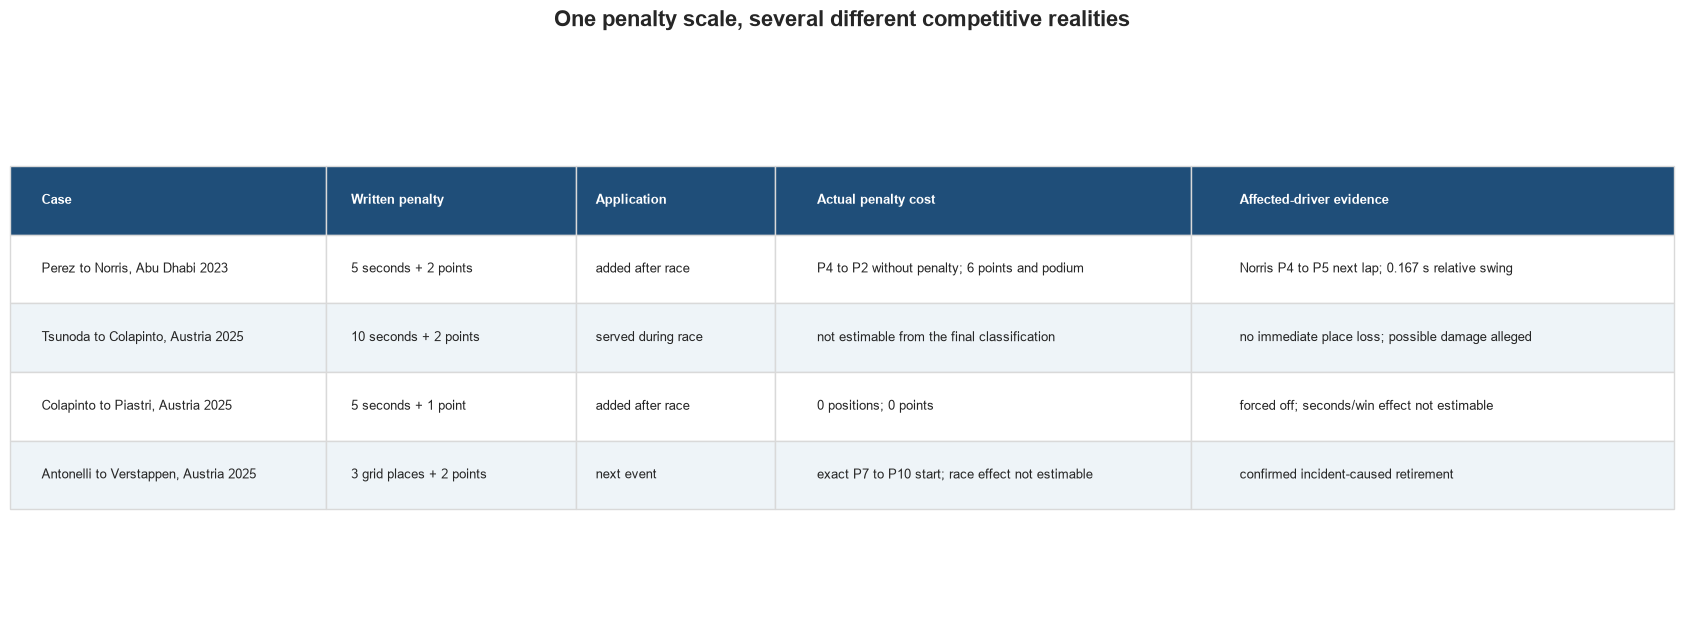

In [6]:
adjudications = pd.read_csv(PILOT / "adjudications.csv")
impacts = pd.read_csv(PILOT / "impact_assessments.csv")
harms = pd.read_csv(PILOT / "harm_assessments.csv")
cross_event = pd.read_csv(PILOT / "cross_event_sanction_effects.csv")

assert len(adjudications) == 9
assert len(impacts) == 4
assert len(harms) == 9
assert set(adjudications["review_status"]) == {"double_coded"}
assert set(impacts["review_status"]) == {"double_coded"}
assert set(harms["review_status"]) == {"double_coded"}

pilot_matrix = pd.DataFrame(
    [
        {
            "case": "Perez to Norris, Abu Dhabi 2023",
            "written penalty": "5 seconds + 2 points",
            "application": "added after race",
            "actual penalty cost": "P4 to P2 without penalty; 6 points and podium",
            "affected-driver evidence": "Norris P4 to P5 next lap; 0.167 s relative swing",
        },
        {
            "case": "Tsunoda to Colapinto, Austria 2025",
            "written penalty": "10 seconds + 2 points",
            "application": "served during race",
            "actual penalty cost": "not estimable from the final classification",
            "affected-driver evidence": "no immediate place loss; possible damage alleged",
        },
        {
            "case": "Colapinto to Piastri, Austria 2025",
            "written penalty": "5 seconds + 1 point",
            "application": "added after race",
            "actual penalty cost": "0 positions; 0 points",
            "affected-driver evidence": "forced off; seconds/win effect not estimable",
        },
        {
            "case": "Antonelli to Verstappen, Austria 2025",
            "written penalty": "3 grid places + 2 points",
            "application": "next event",
            "actual penalty cost": "exact P7 to P10 start; race effect not estimable",
            "affected-driver evidence": "confirmed incident-caused retirement",
        },
    ]
)
display(pilot_matrix)

harm_summary = pd.Series(
    {
        "affected-driver records": len(harms),
        "fault-established records": int(
            (harms["responsibility_status"] == "fault_established").sum()
        ),
        "confirmed damage records": int((harms["damage_evidence"] == "confirmed").sum()),
        "alleged damage records": int((harms["damage_evidence"] == "alleged").sum()),
        "incident-caused retirements": int((harms["retirement_status"] == "incident_caused").sum()),
        "incident-responsive repair stops": int((harms["repair_stop_required"] == "yes").sum()),
        "observed positive position losses": int((harms["net_positions_lost_observed"] > 0).sum()),
        "persistent pace estimates released": int(
            harms["persistent_loss_seconds_estimate"].notna().sum()
        ),
    },
    name="count",
)
display(harm_summary.to_frame())

table_fig, table_ax = plt.subplots(figsize=(17, 6.5))
table_ax.axis("off")
wrapped = pilot_matrix.copy()
wrapped.columns = [
    "Case",
    "Written penalty",
    "Application",
    "Actual penalty cost",
    "Affected-driver evidence",
]
table = table_ax.table(
    cellText=wrapped.values,
    colLabels=wrapped.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.19, 0.15, 0.12, 0.25, 0.29],
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 3.6)
for (row, _col), cell in table.get_celld().items():
    cell.set_edgecolor("#d9d9d9")
    if row == 0:
        cell.set_facecolor("#1f4e79")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#eef4f8")
table_ax.set_title(
    "One penalty scale, several different competitive realities",
    fontsize=16,
    weight="bold",
    pad=18,
)
plt.tight_layout()
table_fig.savefig(GENERATED / "pilot_harm_sanction_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

The pilot covers nine decisions from Austria 2019, Abu Dhabi 2023, and Austria 2025. Independent
reviewers agreed on all 26 case, impact, harm, location, relationship, and cross-event records.

The pilot does not show that any penalty was necessarily unfair. It shows why the number written in
a decision is incomplete:

- Perez's post-race five seconds cost two places, six points, and a podium.
- Colapinto's post-race five seconds changed no place and no points.
- Tsunoda served ten seconds during the race. Because that changed strategy and traffic, subtracting
  ten seconds from his final time would be misleading.
- Antonelli's delayed penalty moved his next start from P7 to P10, but the wet-race result depended
  on too many other factors to isolate.

Harm also takes different forms. The pilot includes an incident-caused retirement, a next-lap
position loss, alleged damage without an immediate place loss, and an off-track excursion whose time
cost could not be isolated. No lasting per-lap damage estimate met the clean-lap evidence rule.
Severe harm does not by itself prove fault, and a conduct penalty is not automatic compensation.

## 6. Public-guideline audit: a bounded pilot finding

In [7]:
guideline_pilot = adjudications.loc[
    adjudications["guideline_regime"] == "public_driving_and_penalty_guidelines",
    ["adjudication_id", "incident_family", "outcome_family", "conformance_status", "coding_notes"],
]
display(guideline_pilot)
display(guideline_pilot["conformance_status"].value_counts().rename("cases").to_frame())
assert len(guideline_pilot) == 5
assert set(guideline_pilot["conformance_status"]) == {"conformant", "mitigated"}

,adjudication_id,incident_family,outcome_family,conformance_status,coding_notes
4,adj-2025-aut-r31-t4-22,causing_collision,time_penalty,conformant,Official reason says Car 22 was fully at fault and did not earn the corner; 2 points are within the published 3-poin...
5,adj-2025-aut-r4-t3-43,forcing_off_track,no_further_action,conformant,Official reason finds Car 87 lacked outside-overlap priority so Car 43 could use the regular racing line; lap is sup...
6,adj-2025-aut-r54-t34-43,forcing_off_track,time_penalty,mitigated,Decision explicitly mitigates because Car 22 obscured Car 81; race-control evidence places the event on global lap 5...
7,adj-2025-aut-r1-t3-12,causing_collision,grid_penalty,conformant,Decision says Car 12 was fully at fault but records evasive action and a non-blatant move; grid penalty was used bec...
8,adj-2025-aut-r15-t3-22,forcing_off_track,no_further_action,conformant,Doc 46 appears to replace unavailable recalled Doc 39; the reason finds all inside-overtake requirements satisfied a...


,cases
conformance_status,
conformant,4
mitigated,1


All five independently reviewed 2025 Austrian decisions either matched the public guideline or
explained a mitigating factor: four matched the baseline and one was mitigated. This shows that the
method can separate a guideline match, mitigation, and a departure. It is not a league-wide 2025
rate because only this pilot received independent human double review.

## 7. How to make the study stronger

The review solved the largest labeling bottleneck, but it also showed where the next effort will
matter more than another broad model.

1. **Add an independent human audit where risk is highest.** Recheck corrected/recalled documents,
   parser warnings, family conflicts, multi-car incidents, and a fresh exclusion sample. Publish
   disagreement by field. This is more feasible and informative than treating every administrative
   document as equally risky.
2. **Study the referral stage.** Formal FIA PDFs show incidents that reached a decision. Race
   Control messages could add the path from "noted" to "investigated" to "formally decided." That
   would make the missing-denominator problem smaller and measurable.
3. **Compare close case pairs.** Match incidents on rule era, session, lap phase, responsibility
   wording, position return, and stated mitigation. Show the source text for close pairs before
   fitting a larger model.
4. **Separate conduct from consequence.** A consistency analysis should ask whether similar conduct
   received similar penalties. A consequence analysis should separately measure harm to the
   affected driver and cost to the penalized driver.
5. **Estimate damage on a representative sample.** Use clean laps and suitable teammate or field
   controls. Report uncertainty and retain "not estimable" whenever safety cars, traffic, weather,
   or strategy destroy the comparison.
6. **Keep nationality secondary.** Prespecify the smallest difference that matters. If the sample
   cannot detect it, report the design limit instead of making nationality the headline.

## 8. Conclusion and recommendations

### Conclusion

The model-reviewed public record does not prove that Formula 1 stewarding was systematically
inconsistent or nationally biased from 2018 through 2025. It also does not clear the system of
either problem. Formal decisions omit incidents that were never referred, broad case categories do
not capture the facts that drive a ruling, and the nationality comparison is too small for subtle
effects.

The full-corpus finding is narrower but useful: 214 of 346 formal cases received a sanction, yet
incident type, season, and multi-car status barely predict which cases did. The right response is
not to label the residuals as bad decisions. It is to collect the missing decision context and make
close, source-based comparisons.

The strongest finding remains that **the penalty column alone cannot measure competitive fairness**.
A useful audit needs four linked facts: who was found responsible, the written penalty, what that
penalty actually cost, and the harm to each affected driver.

### Recommendations to the FIA

1. **Publish structured decisions.** Add stable incident and decision IDs, driver roles,
   session/lap/turn, finding, penalty timing, and version status.
2. **Version the guidance.** Publish the exact guideline active at each event and identify the
   normal sanction plus any written aggravating or mitigating factors.
3. **Report consequences separately.** Keep seconds, starting positions, finishing positions,
   points, repairs, damage, and retirement separate instead of combining them into one fairness
   score.
4. **Show the referral boundary.** Publish what was noted, investigated, formally decided, and not
   referred.
5. **Use models to guide review.** A model can identify cases that deserve comparison; it cannot
   decide that a steward was wrong.

### Evidence status

| Finding | Review level | Decision |
|---|---|---|
| 2018-2025 source inventory and lineage | Source-verified | Reportable |
| Full-corpus sanction rates | GPT-5.6 Sol model review | Descriptive release; no causal claim |
| Broad consistency model | GPT-5.6 Sol model review | Weak result; no wrong-decision ranking |
| Pilot penalty-cost calculations | Independent human double review | Reportable for pilot cases |
| Pilot harm and guideline audit | Human double review | Case study; no population rate |
| British-driver association | Underpowered | Inconclusive |
| Panel-nationality association | Incomplete source evidence | Withheld |

The project demonstrates an auditable data workflow: source history is preserved, Python and
DuckDB transformations are tested, FastF1 timing data are kept separate from FIA fault findings,
changes are traceable, the Jupyter report is executable, and the Snowflake/Snowsight package can be
validated without credentials. Just as importantly, the report says where model review ends and
independent human assurance has not occurred.

## Technical appendix: reproducibility and limitations

- **Population:** 173 completed F1 championship events, 2018-2025; Race and Sprint primary sessions.
- **Primary unit:** one accused-driver adjudication; multi-car affected roles remain separate.
- **Model-review run:** `model-review-3dacc1268f13`, GPT-5.6 Sol, 4,441 queue obligations covering
  2,003 unique FIA source records, zero unresolved rows, four metadata-only exclusions.
- **Review boundary:** model-led second pass using extracted FIA evidence, structured checks, and
  targeted source inspection; no claim of independent human review or line-by-line rereading of
  every original PDF. First- and second-pass errors can be correlated.
- **Authorities:** FIA decisions and classifications; FastF1 is used for timing, not fault.
- **Storage/query:** typed Parquet exports and DuckDB schemas; Snowflake/Snowsight SQL is locally
  validated but not claimed as remotely deployed.
- **Validation:** 19 protected-workspace controls, source and coding completeness, exclusion-sample
  review, identity and outcome checks, grouped model validation, tests, checksums, and content-
  addressed outputs.
- **Referral limitation:** incidents never formally sent to the stewards are not in the denominator.
- **Power limitation:** the nationality design is not powered for subtle associations.
- **Counterfactual limitation:** for in-race penalties, repairs, and race outcomes, the result
  without the penalty or incident usually cannot be found by simple time subtraction.
- **Causal limitation:** an observed position or time change does not prove what would have happened
  without the incident.

Rebuild the model-reviewed workspace with `python scripts/build_model_review_release.py`, rebuild
the feature layer with `f1stewards build-analysis-features --strict-release`, execute notebooks
04-06, run `pytest` and `ruff check`, and inspect `analysis.feature_release_controls` before
interpreting the result tables.